# EDA for Customer Intent Predictor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)

Matplotlib is building the font cache; this may take a moment.


## Features:

- ProductID: Unique identifier for each product.
- ProductCategory: Category of the consumer electronics product (e.g., Smartphones, Laptops).
- ProductBrand: Brand of the product (e.g., Apple, Samsung).
- ProductPrice: Price of the product ($).
- CustomerAge: Age of the customer.
- CustomerGender: Gender of the customer (0 - Male, 1 - Female).
- PurchaseFrequency: Average number of purchases per year.
- CustomerSatisfaction: Customer satisfaction rating (1 - 5).
- PurchaseIntent (Target Variable): Intent to purchase.

In [3]:
df = pd.read_csv('consumer_electronics_sales_data.csv')
df.head(10)

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0
5,5879,Smartphones,Samsung,373.148325,37,1,8,1,1
6,5880,Smartphones,Samsung,2330.036775,26,1,5,5,1
7,5881,Smartphones,HP,780.101494,35,0,12,5,1
8,5882,Laptops,Other Brands,2264.561583,19,1,3,4,1
9,5883,Laptops,HP,1001.624006,66,1,8,4,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductID             9000 non-null   int64  
 1   ProductCategory       9000 non-null   str    
 2   ProductBrand          9000 non-null   str    
 3   ProductPrice          9000 non-null   float64
 4   CustomerAge           9000 non-null   int64  
 5   CustomerGender        9000 non-null   int64  
 6   PurchaseFrequency     9000 non-null   int64  
 7   CustomerSatisfaction  9000 non-null   int64  
 8   PurchaseIntent        9000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 632.9 KB


In [14]:
# List of categorical columns to inspect
categorical_cols = ['ProductCategory', 'ProductBrand']

# Loop through each column and print unique values along with their count
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"--- {col} ({len(unique_vals)} unique) ---")
    print(unique_vals)
    print()

--- ProductCategory (5 unique) ---
<StringArray>
['Smartphones', 'Smart Watches', 'Tablets', 'Laptops', 'Headphones']
Length: 5, dtype: str

--- ProductBrand (5 unique) ---
<StringArray>
['Other Brands', 'Samsung', 'Sony', 'HP', 'Apple']
Length: 5, dtype: str



In [5]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 9000 rows, 9 columns


In [6]:
# checking if the dataset has null values
df.isnull().sum()

ProductID               0
ProductCategory         0
ProductBrand            0
ProductPrice            0
CustomerAge             0
CustomerGender          0
PurchaseFrequency       0
CustomerSatisfaction    0
PurchaseIntent          0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ProductID,9000.0,10373.500000,2598.220545,5874.000000,8123.750000,10373.500000,12623.25000,14873.000000
ProductPrice,9000.0,1527.429195,829.900898,100.376358,809.165014,1513.024577,2244.41552,2999.852253
CustomerAge,9000.0,43.347000,15.055084,18.000000,30.000000,43.000000,56.00000,69.000000
CustomerGender,9000.0,0.508889,0.499949,0.000000,0.000000,1.000000,1.00000,1.000000
PurchaseFrequency,9000.0,10.054667,5.461328,1.000000,5.000000,10.000000,15.00000,19.000000
CustomerSatisfaction,9000.0,2.996000,1.405301,1.000000,2.000000,3.000000,4.00000,5.000000
PurchaseIntent,9000.0,0.566444,0.495593,0.000000,0.000000,1.000000,1.00000,1.000000


PurchaseIntent
1    56.644444
0    43.355556
Name: proportion, dtype: float64


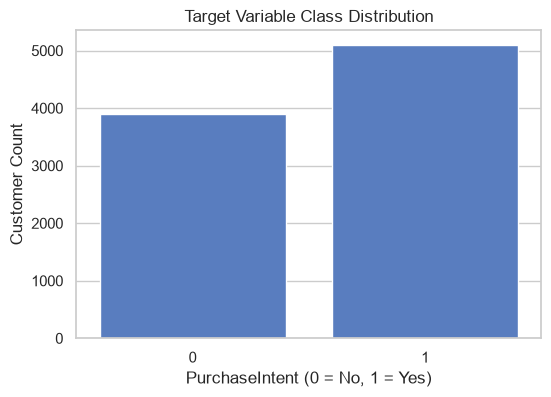

In [8]:
# checking class imbalance for Purchase Intent
print(df['PurchaseIntent'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='PurchaseIntent')
plt.title('Target Variable Class Distribution')
plt.xlabel('PurchaseIntent (0 = No, 1 = Yes)')
plt.ylabel('Customer Count')
plt.show()

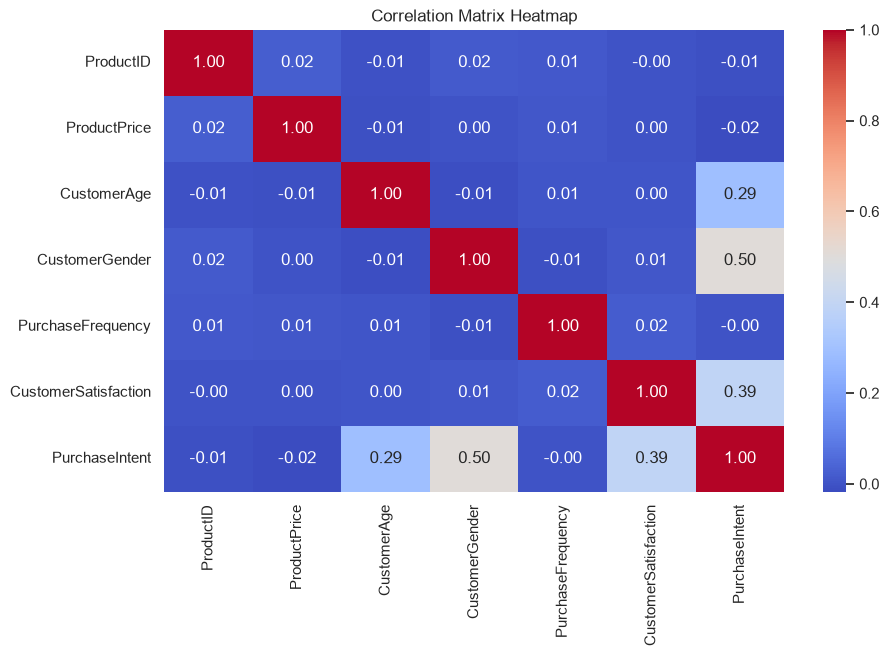

In [9]:
# +1 strong positive correlation, -1 strong negative correlation

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

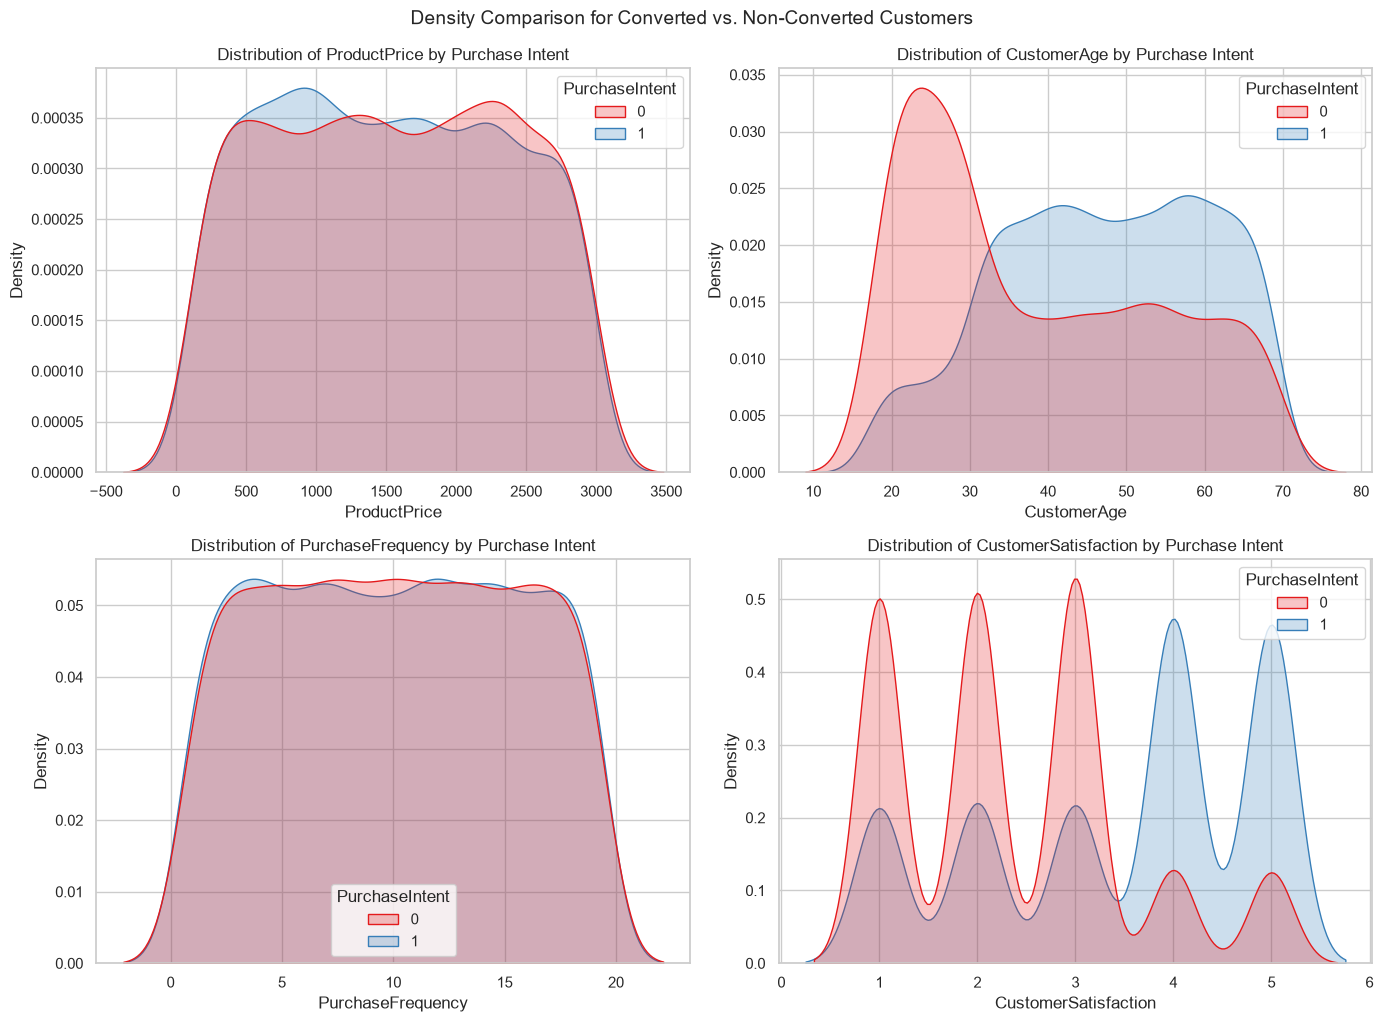

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select key continuous features to plot
continuous_cols = ['ProductPrice', 'CustomerAge', 'PurchaseFrequency', 'CustomerSatisfaction']

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='PurchaseIntent',
        fill=True,          # Fills area under the curve
        common_norm=False,   # Normalizes each class curve independently
        palette='Set1',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col} by Purchase Intent', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.suptitle('Density Comparison for Converted vs. Non-Converted Customers', y=1.02, fontsize=14)
plt.show()

# Preprocessing the dataset

In [13]:
# One-hot encode multi-class categorical features (since we should not assign numbers to these )
categorical_cols = ['ProductCategory', 'ProductBrand']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

df_encoded.head()

,ProductID,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent,ProductCategory_Laptops,ProductCategory_Smart Watches,ProductCategory_Smartphones,ProductCategory_Tablets,ProductBrand_HP,ProductBrand_Other Brands,ProductBrand_Samsung,ProductBrand_Sony
0,5874,312.949668,18,0,2,1,0,0,0,1,0,0,1,0,0
1,5875,980.389404,35,1,7,2,1,0,1,0,0,0,0,1,0
2,5876,2606.718293,63,0,1,5,1,0,0,0,1,0,0,1,0
3,5877,870.395450,63,1,10,3,1,0,0,1,0,0,0,1,0
4,5878,1798.955875,57,0,17,3,0,0,0,0,1,0,0,0,1


In [15]:
# train test split
from sklearn.model_selection import train_test_split

# Separate target variable and feature matrix
X = df_encoded.drop(columns=['PurchaseIntent', 'ProductID'])
y = df_encoded['PurchaseIntent']

# Stratified split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 7200 samples
Testing set size: 1800 samples


In [16]:
# scaling the continusous features using standard scaler

from sklearn.preprocessing import StandardScaler

continuous_features = ['ProductPrice', 'CustomerAge', 'PurchaseFrequency', 'CustomerSatisfaction']

scaler = StandardScaler()

# Copy dataframes to avoid overwriting raw inputs
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler on training data, then transform both train and test sets
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_scaled.head()

,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,ProductCategory_Laptops,ProductCategory_Smart Watches,ProductCategory_Smartphones,ProductCategory_Tablets,ProductBrand_HP,ProductBrand_Other Brands,ProductBrand_Samsung,ProductBrand_Sony
6866,0.242262,0.376702,1,-0.384414,1.423876,0,1,0,0,0,0,0,1
6003,-0.486053,-1.482917,1,0.345727,0.712383,0,0,0,1,1,0,0,0
2731,-0.526952,-1.350087,0,-1.479626,-1.422097,0,1,0,0,0,0,0,0
7291,-0.113248,-0.287448,0,1.258403,0.712383,0,0,0,1,0,1,0,0
5684,-0.585236,1.638586,1,-0.749485,-1.422097,0,0,1,0,0,1,0,0


# Model Training: XGBoost

In [18]:
import xgboost as xgb

# 1. Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=50,      # Number of boosting rounds (trees)
    learning_rate=0.1,     # Step size shrinkage (eta)
    max_depth=5,           # Maximum depth of each tree
    subsample=0.8,         # Fraction of samples used per tree
    colsample_bytree=0.8,  # Fraction of features used per tree
    random_state=42,
    eval_metric='logloss'  # Evaluation metric for binary classification
)

# 2. Train the model on the training set
xgb_model.fit(X_train_scaled, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Model Evaluation

=== Model Evaluation Metrics ===
Accuracy:  0.9394
Precision: 0.9367
Recall:    0.9578
F1-Score:  0.9472
ROC-AUC:   0.9386

=== Detailed Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       780
           1       0.94      0.96      0.95      1020

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800



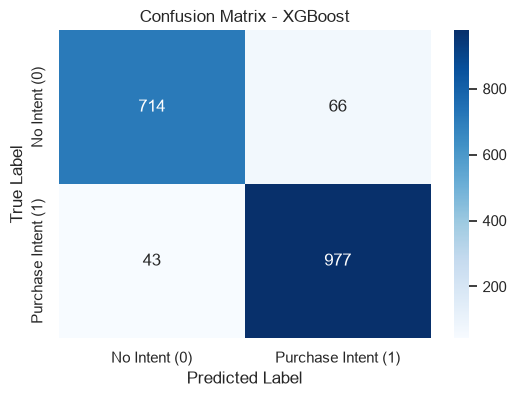

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Predict on the test set
y_pred = xgb_model.predict(X_test_scaled)
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for PurchaseIntent = 1

# 4. Calculate Key Evaluation Metrics
print("=== Model Evaluation Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}")

# Detailed Classification Report
print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred))

# 5. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Intent (0)', 'Purchase Intent (1)'],
            yticklabels=['No Intent (0)', 'Purchase Intent (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()